In [ ]:
import re
from collections import Counter

In [ ]:
def parse_ner_file(path):
    sentences = []
    labels = []

    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    # Satır bazlı ayır
    lines = [l.strip() for l in text.split("\n") if l.strip()]

    for line in lines:
        tokens = []
        tags = []

        while line:
            m = re.search(r"<b_enamex TYPE=\"(.*?)\">(.*?)<e_enamex>", line)
            if not m:
                words = line.split()
                tokens.extend(words)
                tags.extend(["O"] * len(words))
                break

            start, end = m.span()
            before = line[:start].split()
            entity_type = m.group(1)
            entity_words = m.group(2).split()

            tokens.extend(before)
            tags.extend(["O"] * len(before))

            for i, w in enumerate(entity_words):
                prefix = "B-" if i == 0 else "I-"
                tokens.append(w)
                tags.append(prefix + entity_type)

            line = line[end:]

        sentences.append(tokens)
        labels.append(tags)

    return sentences, labels


In [ ]:
sentences, ner_labels = parse_ner_file(
   path="nerdata.txt"
)

label_counter = Counter()
for sent in ner_labels:
    label_counter.update(sent)

print("NER dağılımı:")
for k, v in label_counter.items():
    print(f"{k:15s}: {v}")


NER dağılımı:
O              : 438976
B-ORGANIZATION : 10031
I-ORGANIZATION : 6900
B-LOCATION     : 10889
I-LOCATION     : 1559
B-PERSON       : 16293
I-PERSON       : 7585


In [ ]:
import torch
from torch.utils.data import Dataset


In [ ]:
word2idx = {"<PAD>": 0, "<UNK>": 1}
label2idx = {"PAD": 0}

for sent in sentences:
    for w in sent:
        if w not in word2idx:
            word2idx[w] = len(word2idx)

for lab in label_counter:
    if lab not in label2idx:
        label2idx[lab] = len(label2idx)

idx2label = {v: k for k, v in label2idx.items()}


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    sentences, ner_labels, test_size=0.2, random_state=42
)

In [ ]:
class NERDataset(Dataset):
    def __init__(self, sentences, labels, max_len=128):
        self.sentences = sentences
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        tokens = self.sentences[idx][:self.max_len]
        labs = self.labels[idx][:self.max_len]

        input_ids = [word2idx.get(w, 1) for w in tokens]
        label_ids = [label2idx[l] for l in labs]

        pad_len = self.max_len - len(input_ids)

        input_ids += [0] * pad_len
        label_ids += [0] * pad_len

        return torch.tensor(input_ids), torch.tensor(label_ids)


In [ ]:
import torch.nn as nn


In [ ]:
class TransformerNER(nn.Module):
    def __init__(self, vocab_size, tag_size, d_model=256, nhead=8, num_layers=4):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.dropout = nn.Dropout(0.3)

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dropout=0.3,
            batch_first=True
        )

        self.fc = nn.Linear(d_model, tag_size)

    def forward(self, src, tgt):
        src = self.dropout(self.embedding(src))
        tgt = self.dropout(self.embedding(tgt))

        out = self.transformer(src, tgt)
        return self.fc(out)



In [ ]:
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = TransformerNER(len(word2idx), len(label2idx)).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

train_loader = DataLoader(NERDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(NERDataset(X_test, y_test), batch_size=16)

train_losses, test_losses = [], []
train_accs, test_accs = [], []


In [ ]:
def accuracy(pred, target):
    mask = target != 0
    return (pred[mask] == target[mask]).float().mean().item()


In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss, total_acc = 0, 0

    for x, y in tqdm(train_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x, x)

        loss = criterion(outputs.view(-1, outputs.size(-1)), y.view(-1))
        loss.backward()
        optimizer.step()

        preds = outputs.argmax(-1)
        total_loss += loss.item()
        total_acc += accuracy(preds, y)

    train_losses.append(total_loss / len(train_loader))
    train_accs.append(total_acc / len(train_loader))

    model.eval()
    with torch.no_grad():
        loss_t, acc_t = 0, 0
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x, x)
            loss = criterion(out.view(-1, out.size(-1)), y.view(-1))
            loss_t += loss.item()
            acc_t += accuracy(out.argmax(-1), y)

    test_losses.append(loss_t / len(test_loader))
    test_accs.append(acc_t / len(test_loader))

    print(f"Epoch {epoch+1} | Train Acc {train_accs[-1]:.3f} | Test Acc {test_accs[-1]:.3f}")


100%|██████████| 1378/1378 [01:45<00:00, 13.09it/s]


Epoch 1 | Train Acc 0.892 | Test Acc 0.897


100%|██████████| 1378/1378 [01:45<00:00, 13.11it/s]


Epoch 2 | Train Acc 0.907 | Test Acc 0.917


100%|██████████| 1378/1378 [01:44<00:00, 13.14it/s]


...

Epoch 8 | Train Acc 0.951 | Test Acc 0.953


100%|██████████| 1378/1378 [01:44<00:00, 13.15it/s]


Epoch 9 | Train Acc 0.954 | Test Acc 0.954


100%|██████████| 1378/1378 [01:44<00:00, 13.15it/s]


Epoch 10 | Train Acc 0.957 | Test Acc 0.958


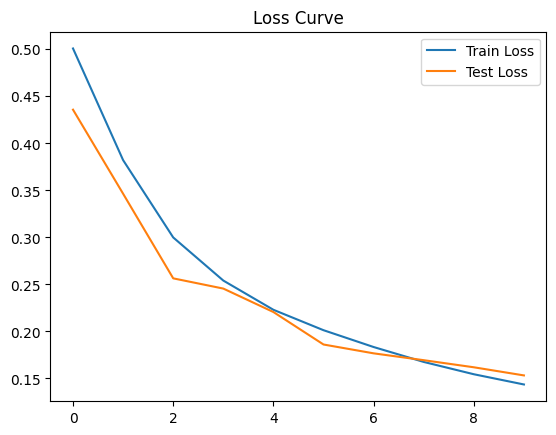

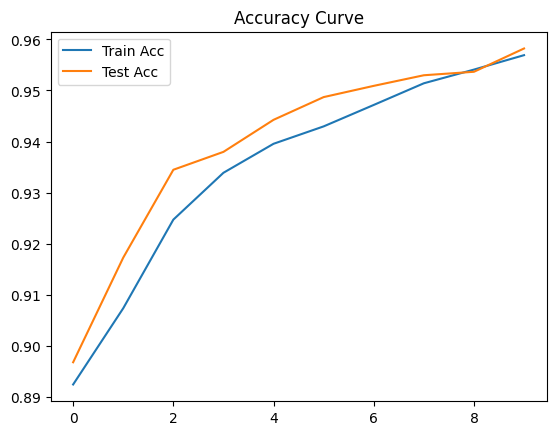

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(test_accs, label="Test Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [ ]:
from sklearn.metrics import classification_report


In [ ]:
all_preds, all_true = [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x, x).argmax(-1).cpu()

        for i in range(x.size(0)):
            for j in range(x.size(1)):
                if y[i, j] != 0:
                    all_preds.append(out[i, j].item())
                    all_true.append(y[i, j].item())


In [ ]:
print(classification_report(
    all_true,
    all_preds,
    target_names=[idx2label[i] for i in range(1, len(idx2label))]
))


                precision    recall  f1-score   support

             O       0.98      0.99      0.99     83985
B-ORGANIZATION       0.84      0.69      0.76      2071
I-ORGANIZATION       0.75      0.71      0.73      1335
    B-LOCATION       0.86      0.77      0.81      2101
    I-LOCATION       0.58      0.49      0.53       305
      B-PERSON       0.81      0.73      0.77      3362
      I-PERSON       0.58      0.45      0.51      1638

      accuracy                           0.96     94797
     macro avg       0.77      0.69      0.73     94797
  weighted avg       0.95      0.96      0.96     94797



In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import (
    BertTokenizerFast,
    BertForTokenClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import classification_report

In [ ]:
tokenizer = BertTokenizerFast.from_pretrained(
    "dbmdz/bert-base-turkish-cased"
)


In [ ]:
def tokenize_and_align_labels(sentences, labels, max_len=128):
    tokenized = tokenizer(
        sentences,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_len
    )

    aligned_labels = []

    for i, label_seq in enumerate(labels):
        word_ids = tokenized.word_ids(batch_index=i)
        prev_word = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev_word:
                label_ids.append(label2idx[label_seq[word_id]])
            else:
                label_ids.append(-100)
            prev_word = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels
    return tokenized


In [ ]:
class BERTNERDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __getitem__(self, idx):
        return {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

    def __len__(self):
        return len(self.encodings["input_ids"])



In [ ]:
train_enc = tokenize_and_align_labels(X_train, y_train)
test_enc  = tokenize_and_align_labels(X_test, y_test)

train_dataset = BERTNERDataset(train_enc)
test_dataset  = BERTNERDataset(test_enc)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = BertForTokenClassification.from_pretrained(
    "dbmdz/bert-base-turkish-cased",
    num_labels=len(label2idx)
).to(device)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dbmdz/bert-base-turkish-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainerCallback
class AccuracyCallback(TrainerCallback):
    def __init__(self, trainer, train_dataset, test_dataset):
        self.trainer = trainer
        self.train_dataset = train_dataset
        self.test_dataset = test_dataset
        self.train_accs = []
        self.test_accs = []

    def on_epoch_end(self, args, state, control, **kwargs):
        train_out = self.trainer.predict(self.train_dataset)
        test_out  = self.trainer.predict(self.test_dataset)

        train_acc = token_accuracy(train_out.predictions, train_out.label_ids)
        test_acc  = token_accuracy(test_out.predictions, test_out.label_ids)

        self.train_accs.append(train_acc)
        self.test_accs.append(test_acc)

        print(
            f"Epoch {int(state.epoch)} | "
            f"Train Acc: {train_acc:.3f} | "
            f"Test Acc: {test_acc:.3f}"
        )


In [ ]:
accuracy_callback = AccuracyCallback(
    trainer=None,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)


In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_ner",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    callbacks=[accuracy_callback]
)
accuracy_callback.trainer = trainer


/tmp/ipython-input-1644346004.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    true_preds = [
        [idx2label[p] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]
    true_labels = [
        [idx2label[l] for p, l in zip(pred, lab) if l != -100]
        for pred, lab in zip(predictions, labels)
    ]

    report = classification_report(true_labels, true_preds, output_dict=True)
    return {
        "precision": report["macro avg"]["precision"],
        "recall": report["macro avg"]["recall"],
        "f1": report["macro avg"]["f1-score"],
    }


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.006400,0.034808
2,0.003900,0.036251
3,0.002100,0.039528
4,0.001600,0.042760
5,0.001400,0.043641


Epoch 1 | Train Acc: 0.999 | Test Acc: 0.993
Epoch 2 | Train Acc: 0.999 | Test Acc: 0.994
Epoch 3 | Train Acc: 1.000 | Test Acc: 0.993
Epoch 4 | Train Acc: 1.000 | Test Acc: 0.993
Epoch 5 | Train Acc: 1.000 | Test Acc: 0.994


TrainOutput(global_step=6890, training_loss=0.003088518445135374, metrics={'train_runtime': 918.6676, 'train_samples_per_second': 119.978, 'train_steps_per_second': 7.5, 'total_flos': 7200422702161920.0, 'train_loss': 0.003088518445135374, 'epoch': 5.0})

In [ ]:
train_losses = []
eval_losses = []
for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log and "eval_loss" not in log:
        train_losses.append(log["loss"])

    if "eval_loss" in log:
        eval_losses.append(log["eval_loss"])

min_len = min(len(train_losses), len(eval_losses))
train_losses = train_losses[:min_len]
eval_losses = eval_losses[:min_len]


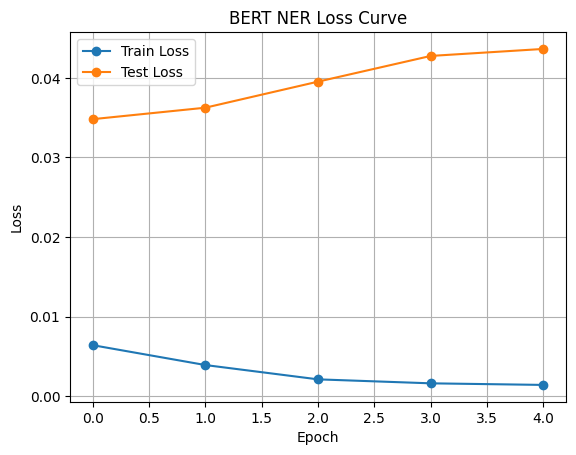

In [ ]:
plt.figure()
plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(eval_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT NER Loss Curve")
plt.legend()
plt.grid()
plt.show()


In [ ]:
import numpy as np

def token_accuracy(preds, labels):
    preds = np.argmax(preds, axis=2)
    correct, total = 0, 0

    for p_seq, l_seq in zip(preds, labels):
        for p, l in zip(p_seq, l_seq):
            if l != -100:
                total += 1
                if p == l:
                    correct += 1
    return correct / total


In [ ]:
train_out = trainer.predict(train_dataset)
test_out  = trainer.predict(test_dataset)

train_acc = token_accuracy(train_out.predictions, train_out.label_ids)
test_acc  = token_accuracy(test_out.predictions, test_out.label_ids)

print("Train Accuracy:", round(train_acc, 3))
print("Test  Accuracy:", round(test_acc, 3))


Train Accuracy: 1.0
Test  Accuracy: 0.994


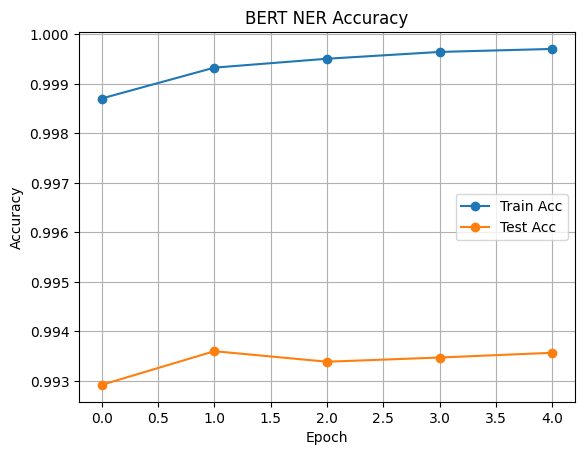

In [ ]:
plt.figure()
plt.plot(accuracy_callback.train_accs, marker="o", label="Train Acc")
plt.plot(accuracy_callback.test_accs, marker="o", label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BERT NER Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
preds = np.argmax(test_out.predictions, axis=2)
labels = test_out.label_ids

all_preds, all_true = [], []

for p_seq, l_seq in zip(preds, labels):
    for p, l in zip(p_seq, l_seq):
        if l != -100:
            all_preds.append(p)
            all_true.append(l)


In [ ]:
print(classification_report(
    all_true,
    all_preds,
    target_names=[idx2label[i] for i in range(1, len(idx2label))]
))


                precision    recall  f1-score   support

             O       1.00      1.00      1.00     83201
B-ORGANIZATION       0.95      0.96      0.96      2057
I-ORGANIZATION       0.95      0.95      0.95      1320
    B-LOCATION       0.97      0.97      0.97      2081
    I-LOCATION       0.89      0.90      0.89       303
      B-PERSON       0.97      0.98      0.97      3329
      I-PERSON       0.97      0.97      0.97      1619

      accuracy                           0.99     93910
     macro avg       0.96      0.96      0.96     93910
  weighted avg       0.99      0.99      0.99     93910

